In [2]:
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd


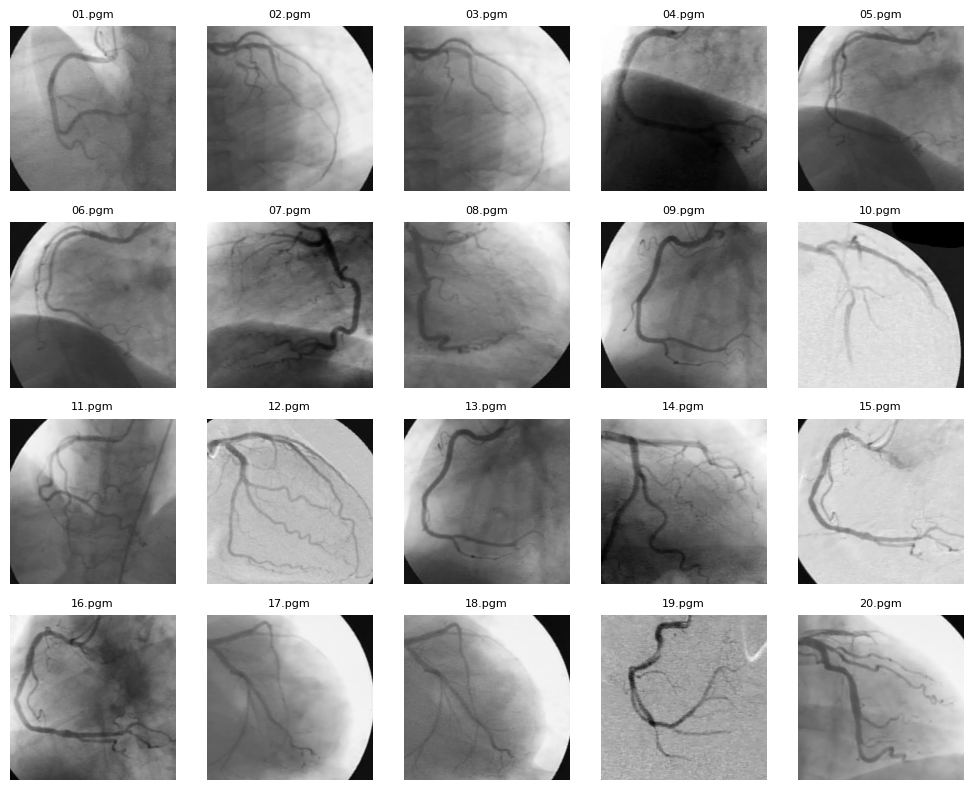

In [3]:
# Folder containing the PGM images
image_folder = "database"

# Read all .pgm files to binarize
image_files = [f for f in os.listdir(image_folder) if not f.endswith("_gt.pgm")]

# Load images
images = [cv2.imread(os.path.join(image_folder, f), cv2.IMREAD_GRAYSCALE) for f in image_files]

# Display images in a grid
cols = 5  # 5 columns
rows = 4  # 4 rows (since we have 20 images)
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for ax, img, name in zip(axes.ravel(), images, image_files):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


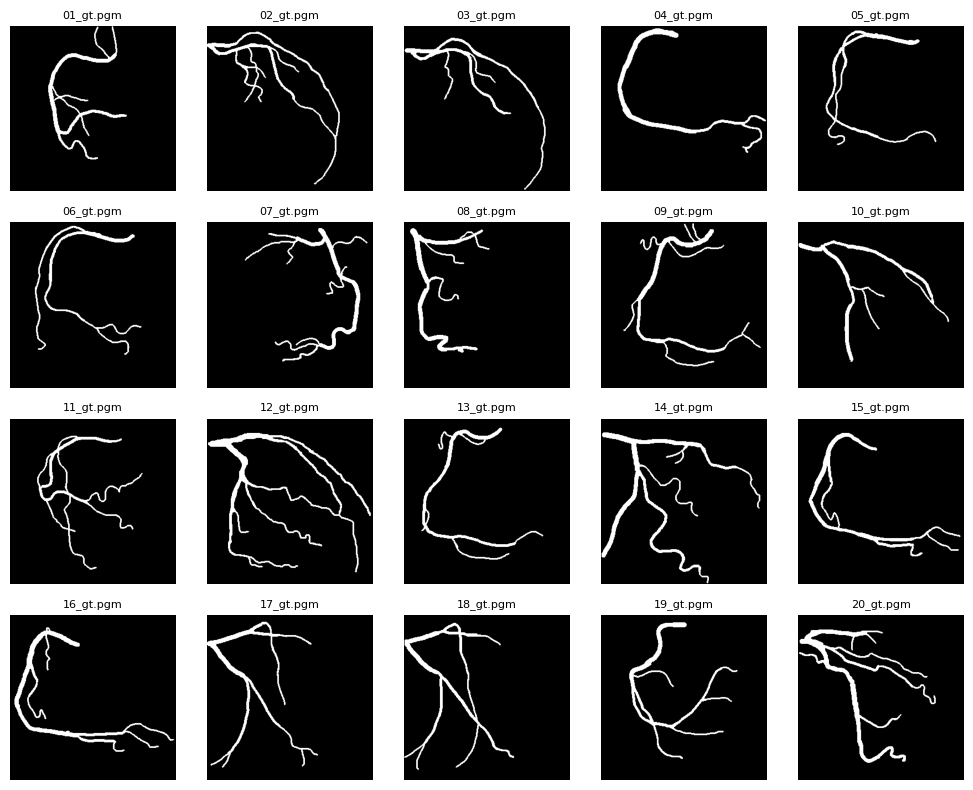

In [4]:
# Folder containing the PGM images
image_folder = "database"

# Read all .pgm files
image_files_control = [f for f in os.listdir(image_folder) if f.endswith("_gt.pgm")]

# Load images
images_control = [cv2.imread(os.path.join(image_folder, f), cv2.IMREAD_GRAYSCALE) for f in image_files_control] 

# Display images in a grid
cols = 5  # 5 columns
rows = 4  # 4 rows (since we have 20 images)
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for ax, img, name in zip(axes.ravel(), images_control, image_files_control):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [5]:
def adaptive_mean_threshold(img, block_size=15, C=5):
    """
    Apply adaptive mean thresholding manually.
    img: Grayscale image (numpy array)
    block_size: Size of the local neighborhood (must be odd)
    C: Constant subtracted from mean
    """
    padded = cv2.copyMakeBorder(img, block_size//2, block_size//2, block_size//2, block_size//2, cv2.BORDER_REFLECT)
    result = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded[i:i+block_size, j:j+block_size]
            local_mean = np.mean(block)
            result[i, j] = 255 if img[i, j] > (local_mean - C) else 0

    return result


In [6]:
def sauvola_threshold(image, window_size=25, k=0.1, R=128):
    img = image.astype(np.float32)
    mean = cv2.boxFilter(img, cv2.CV_32F, (window_size, window_size))
    mean_sq = cv2.boxFilter(img**2, cv2.CV_32F, (window_size, window_size))
    std = np.sqrt(mean_sq - mean**2)
    
    thresh = mean * (1 + k * ((std / R) - 1))
    binary = (img > thresh).astype(np.uint8) * 255
    return binary

In [7]:
def niblack_threshold(img, block_size=15, k=-0.2):
    """
    Manual implementation of Niblack thresholding.
    img: Grayscale image (numpy array)
    block_size: Size of the local window (must be odd)
    k: Niblack parameter (commonly -0.2)
    """
    padded = cv2.copyMakeBorder(img, block_size//2, block_size//2,
                                 block_size//2, block_size//2, cv2.BORDER_REFLECT)
    result = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded[i:i+block_size, j:j+block_size]
            local_mean = np.mean(block)
            local_std = np.std(block)

            threshold = local_mean + k * local_std
            result[i, j] = 255 if img[i, j] > threshold else 0

    return result


In [8]:
def nick_threshold(img, block_size=15, k=-0.6):
    """
    Apply Nick thresholding manually.
    img: Grayscale image (numpy array)
    block_size: Size of the local neighborhood (must be odd)
    k: Constant to adjust the threshold (typically negative)
    """
    # Pad the image to handle edge pixels
    padded = cv2.copyMakeBorder(img, block_size//2, block_size//2, block_size//2, block_size//2, cv2.BORDER_REFLECT)
    result = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # Extract the local neighborhood
            block = padded[i:i+block_size, j:j+block_size]
            local_mean = np.mean(block)
            local_std = np.std(block)

            # Compute the threshold
            threshold = local_mean + k * local_std

            # Binarize the pixel
            result[i, j] = 255 if img[i, j] > threshold else 0

    return result

In [9]:
def otsu_threshold(img):
    """
    Manually apply Otsu's thresholding.
    img: Grayscale image (numpy array)
    """
    # Compute histogram and probabilities
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
    total_pixels = img.size
    prob = hist / total_pixels  # Probability distribution of intensities

    # Initialize variables to track maximum variance and optimal threshold
    max_variance = 0
    optimal_threshold = 0

    # Iterate over all possible thresholds (0 to 255)
    for t in range(1, 256):
        # Split histogram into background (<= t) and foreground (> t)
        w0 = np.sum(prob[:t])   # Weight of background class
        w1 = np.sum(prob[t:])   # Weight of foreground class

        if w0 == 0 or w1 == 0:
            continue  # Avoid division by zero

        # Mean intensities of background and foreground
        mu0 = np.sum(np.arange(t) * prob[:t]) / w0
        mu1 = np.sum(np.arange(t, 256) * prob[t:]) / w1

        # Compute between-class variance
        between_variance = w0 * w1 * (mu0 - mu1) ** 2

        # Update optimal threshold if variance is larger
        if between_variance > max_variance:
            max_variance = between_variance
            optimal_threshold = t

    # Apply the optimal threshold to the image
    binary_img = (img > optimal_threshold).astype(np.uint8) * 255
    return binary_img


## Evaluate and Visualize Binarizations

In [10]:
def evaluate_binarization(binarize_fn, image_files, control_files, image_folder):
    results = []

    for img_name, gt_name in zip(image_files, control_files):
        img_path = os.path.join(image_folder, img_name)
        gt_path = os.path.join(image_folder, gt_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
        gt = cv2.bitwise_not(gt)

        # Ground truth is assumed to be 0 (background) and 255 (foreground)
        gt_binary = (gt > 127).astype(np.uint8)
        result = binarize_fn(img)
        result_binary = (result > 127).astype(np.uint8)

        # Flatten arrays
        gt_flat = gt_binary.flatten()
        result_flat = result_binary.flatten()

        # Compute confusion matrix: [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = confusion_matrix(gt_flat, result_flat, labels=[0, 1]).ravel()

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        recall = tp / (tp + fn) if (tp + fn) else 0
        specificity = tn / (tn + fp) if (tn + fp) else 0
        precision = tp / (tp + fp) if (tp + fp) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        results.append({
            "Image": img_name,
            "Accuracy": accuracy,
            "Recall": recall,
            "Specificity": specificity,
            "Precision": precision,
            "F1 Score": f1
        })

    # Show 5 random images with the gt image on the first row and the result on the second row
    random_indices = np.random.choice(len(image_files), 5, replace=False)
    #print(f"==>> random_indices:\n {random_indices}")
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    selected_indices = [6,7,8,9,10]
    print(f"==>> selected_indices:\n {selected_indices}")

    for i, idx in enumerate(selected_indices):
      img_name = image_files[idx]
      gt_name = img_name.replace(".pgm", "_gt.pgm")

      img_path = os.path.join(image_folder, img_name)
      gt_path = os.path.join(image_folder, gt_name)

      img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
      gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
      gt = cv2.bitwise_not(gt)

      result = binarize_fn(img)

      axes[0, i].imshow(gt, cmap="gray")
      axes[0, i].set_title(f"GT: {gt_name}", fontsize=8)
      axes[0, i].axis("off")

      axes[1, i].imshow(result, cmap="gray")
      axes[1, i].set_title(f"Result: {img_name}", fontsize=8)
      axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(results)
    avg = df.drop(columns=["Image"]).mean()
    avg["Image"] = "AVG"
    df = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)

    
    return df


In [11]:
image_folder = "database"

image_files = [f for f in os.listdir(image_folder) if f.endswith(".pgm") and not f.endswith("_gt.pgm")]
control_files = [f for f in os.listdir(image_folder) if f.endswith("_gt.pgm")]


==>> selected_indices:
 [6, 7, 8, 9, 10]


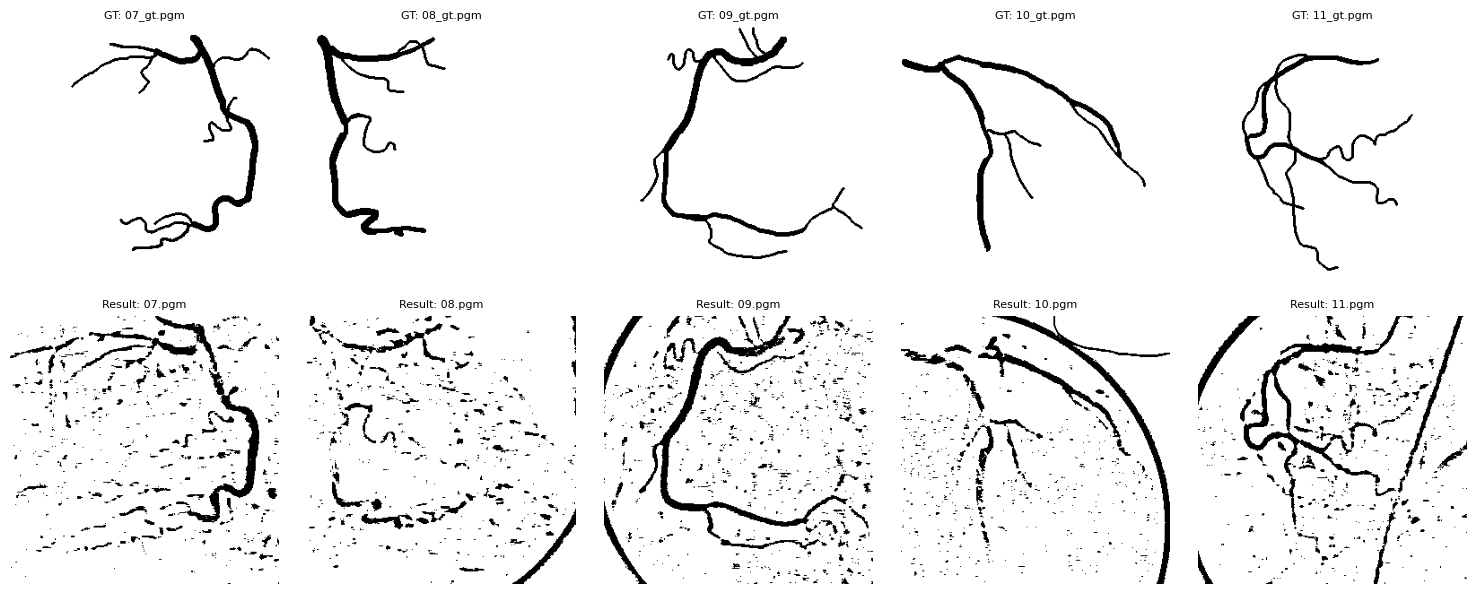

,Image,Accuracy,Recall,Specificity,Precision,F1 Score
0,01.pgm,0.933744,0.941753,0.751124,0.988544,0.964581
1,02.pgm,0.938322,0.942100,0.862053,0.992799,0.966785
2,03.pgm,0.944333,0.948559,0.847584,0.993032,0.970286
3,04.pgm,0.940578,0.962882,0.458134,0.974643,0.968727
4,05.pgm,0.931478,0.937368,0.774501,0.991054,0.963464
5,06.pgm,0.932078,0.934685,0.863193,0.994491,0.963661
6,07.pgm,0.935189,0.944957,0.746501,0.986302,0.965187
7,08.pgm,0.925922,0.948893,0.456537,0.972735,0.960666
8,09.pgm,0.922722,0.925179,0.876937,0.992914,0.957850
9,10.pgm,0.928633,0.941326,0.651976,0.983321,0.961865


In [12]:

# Evaluate adaptive mean thresholding
evaluate_binarization(adaptive_mean_threshold, image_files, control_files, image_folder)


==>> selected_indices:
 [6, 7, 8, 9, 10]


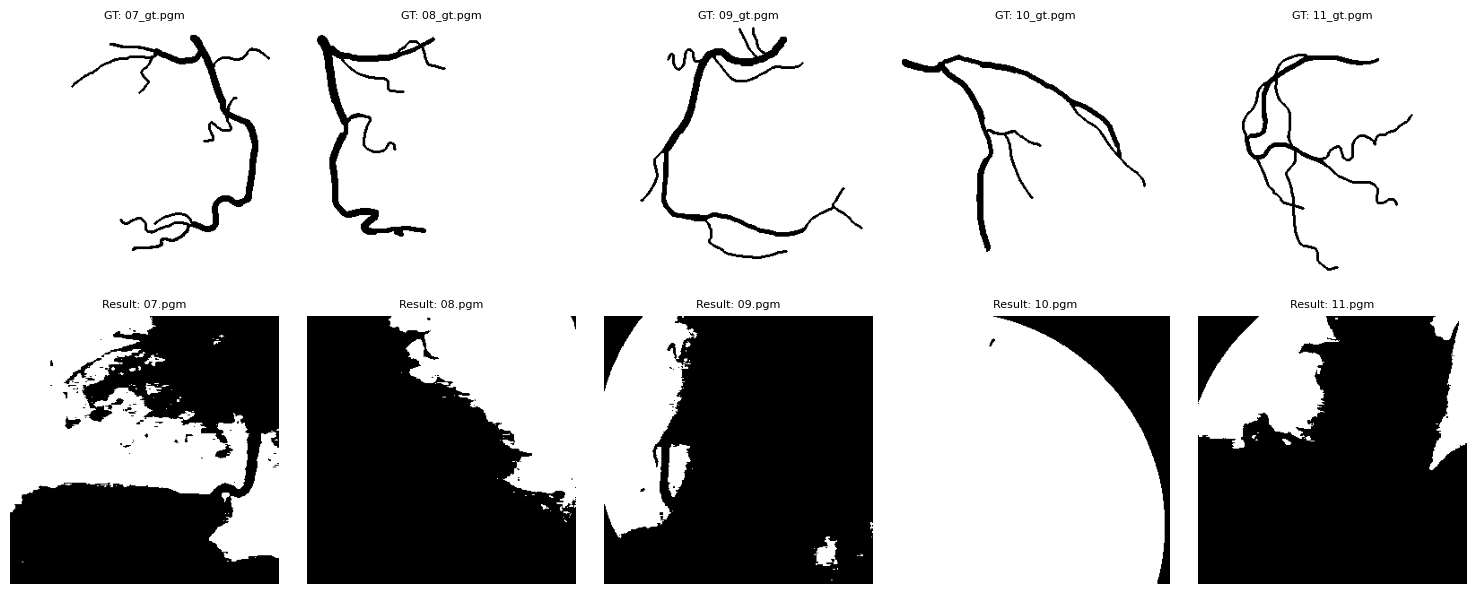

,Image,Accuracy,Recall,Specificity,Precision,F1 Score
0,01.pgm,0.331044,0.309317,0.826501,0.975993,0.469756
1,02.pgm,0.489011,0.479033,0.690443,0.968981,0.641117
2,03.pgm,0.471956,0.462207,0.695167,0.972004,0.626501
3,04.pgm,0.448144,0.437023,0.688710,0.968119,0.602203
4,05.pgm,0.560422,0.560355,0.562212,0.971519,0.710758
5,06.pgm,0.604578,0.610415,0.450335,0.967043,0.748416
6,07.pgm,0.493944,0.468505,0.985327,0.998381,0.637741
7,08.pgm,0.318778,0.286547,0.977376,0.996151,0.445068
8,09.pgm,0.244789,0.205603,0.975125,0.993551,0.340702
9,10.pgm,0.804189,0.841084,0.000000,0.948274,0.891469


In [13]:
evaluate_binarization(otsu_threshold, image_files, control_files, image_folder)


==>> selected_indices:
 [6, 7, 8, 9, 10]


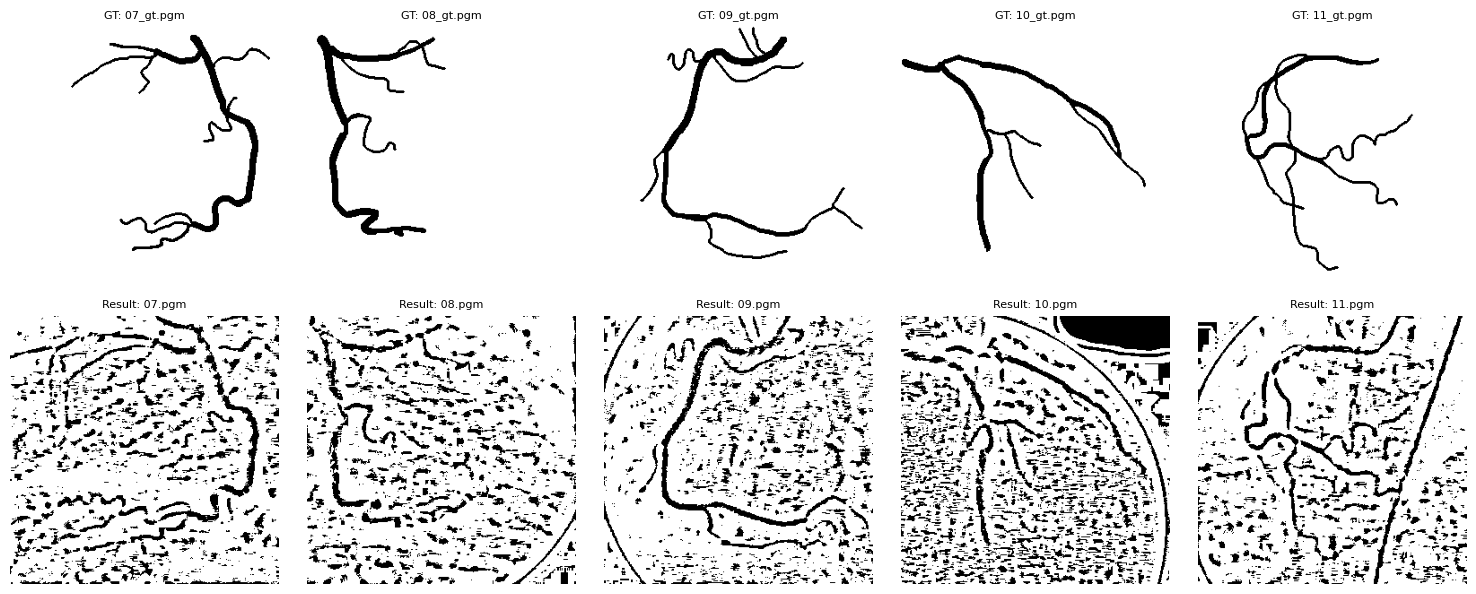

,Image,Accuracy,Recall,Specificity,Precision,F1 Score
0,01.pgm,0.825444,0.829318,0.737107,0.986289,0.901018
1,02.pgm,0.862800,0.865473,0.808851,0.989177,0.923199
2,03.pgm,0.854300,0.859127,0.743760,0.987142,0.918697
3,04.pgm,0.830411,0.843286,0.551924,0.976024,0.904813
4,05.pgm,0.845067,0.847761,0.773272,0.990064,0.913403
5,06.pgm,0.847222,0.848786,0.805911,0.991420,0.914575
6,07.pgm,0.838989,0.844467,0.733183,0.983906,0.908869
7,08.pgm,0.837889,0.848370,0.623720,0.978755,0.908910
8,09.pgm,0.858644,0.863704,0.764346,0.985572,0.920622
9,10.pgm,0.747078,0.749303,0.698582,0.981879,0.849968


In [14]:
evaluate_binarization(nick_threshold, image_files, control_files, image_folder)

==>> selected_indices:
 [6, 7, 8, 9, 10]


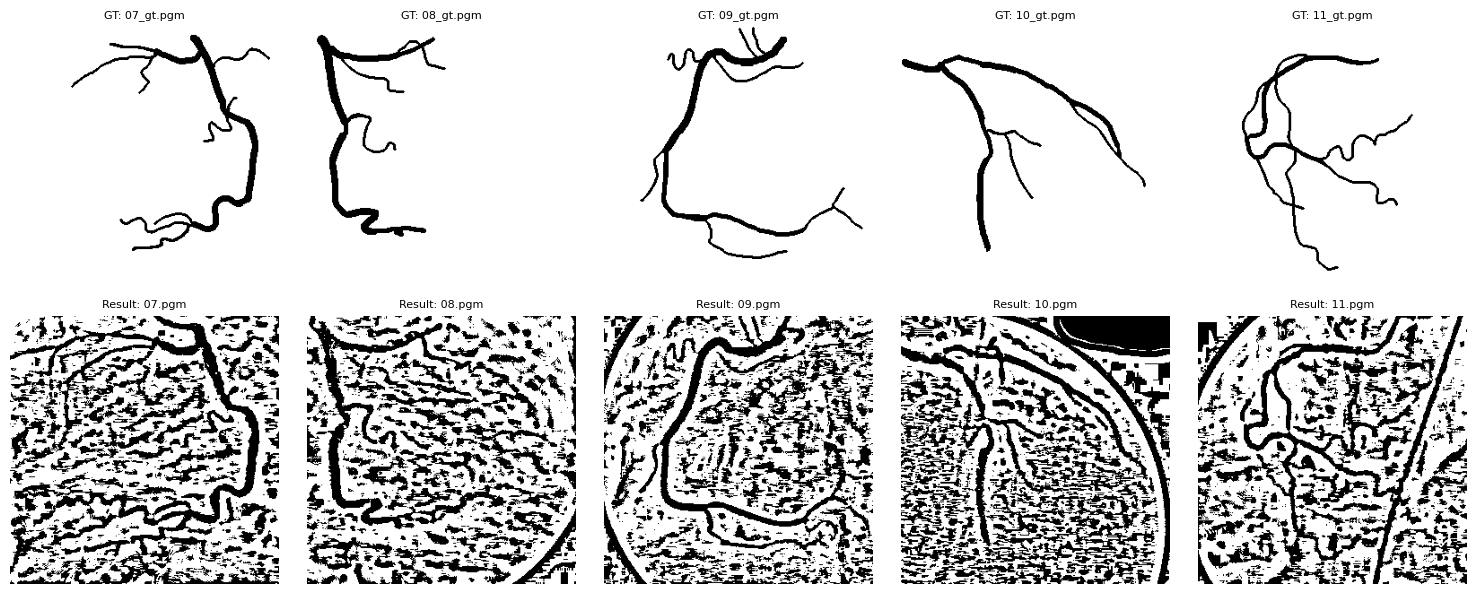

,Image,Accuracy,Recall,Specificity,Precision,F1 Score
0,01.pgm,0.662278,0.650935,0.920920,0.994701,0.786913
1,02.pgm,0.703222,0.690829,0.953390,0.996669,0.816034
2,03.pgm,0.697811,0.687038,0.944503,0.996485,0.813322
3,04.pgm,0.662178,0.652326,0.875283,0.991238,0.786839
4,05.pgm,0.655933,0.645121,0.944086,0.996758,0.783285
5,06.pgm,0.657711,0.646498,0.953991,0.997314,0.784471
6,07.pgm,0.679367,0.665630,0.944695,0.995717,0.797882
7,08.pgm,0.681078,0.670552,0.896166,0.992479,0.800356
8,09.pgm,0.694122,0.680871,0.941087,0.995379,0.808620
9,10.pgm,0.593256,0.579417,0.894883,0.991745,0.731477


In [15]:
evaluate_binarization(niblack_threshold, image_files, control_files, image_folder)

==>> selected_indices:
 [6, 7, 8, 9, 10]


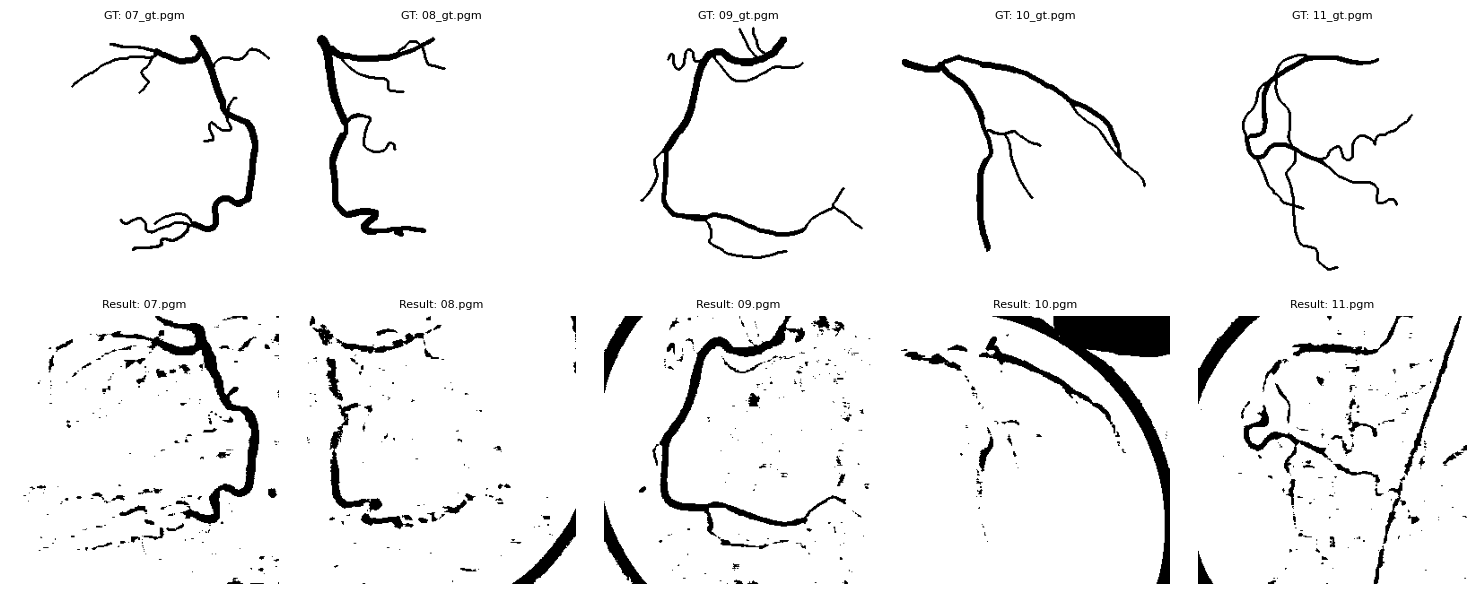

,Image,Accuracy,Recall,Specificity,Precision,F1 Score
0,01.pgm,0.951900,0.963836,0.679714,0.985637,0.974615
1,02.pgm,0.946644,0.962508,0.626412,0.981135,0.971732
2,03.pgm,0.958089,0.972377,0.630908,0.983693,0.978003
3,04.pgm,0.966722,0.995164,0.351521,0.970755,0.982808
4,05.pgm,0.936856,0.943340,0.764055,0.990702,0.966441
5,06.pgm,0.934689,0.941546,0.753504,0.990189,0.965255
6,07.pgm,0.955889,0.963749,0.804063,0.989584,0.976496
7,08.pgm,0.952656,0.967833,0.642534,0.982246,0.974986
8,09.pgm,0.939989,0.946709,0.814750,0.989610,0.967684
9,10.pgm,0.865122,0.883431,0.466059,0.973019,0.926063


In [16]:
evaluate_binarization(sauvola_threshold, image_files, control_files, image_folder)

### Evaluate the functions with LaTeX

In [48]:
def evaluate_binarization_latex(binarize_fn, image_files, control_files, image_folder):
    results = []

    for img_name, gt_name in zip(image_files, control_files):
        img_path = os.path.join(image_folder, img_name)
        gt_path = os.path.join(image_folder, gt_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
        gt = cv2.bitwise_not(gt)

        # Ground truth is assumed to be 0 (background) and 255 (foreground)
        gt_binary = (gt > 127).astype(np.uint8)
        result = binarize_fn(img)
        result_binary = (result > 127).astype(np.uint8)

        # Flatten arrays
        gt_flat = gt_binary.flatten()
        result_flat = result_binary.flatten()

        # Compute confusion matrix: [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = confusion_matrix(gt_flat, result_flat, labels=[0, 1]).ravel()

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        recall = tp / (tp + fn) if (tp + fn) else 0
        specificity = tn / (tn + fp) if (tn + fp) else 0
        precision = tp / (tp + fp) if (tp + fp) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        results.append({
            "Image": img_name,
            "Accuracy": accuracy,
            "Recall": recall,
            "Specificity": specificity,
            "Precision": precision,
            "F1 Score": f1
        })

    df = pd.DataFrame(results)
    avg = df.drop(columns=["Image"]).mean()
    avg["Image"] = "AVG"
    df = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)
    
    return df


In [49]:
adaptive_df = evaluate_binarization_latex(adaptive_mean_threshold, image_files, control_files, image_folder)

In [50]:
otsu_df = evaluate_binarization_latex(otsu_threshold, image_files, control_files, image_folder)

In [51]:
niblack_df = evaluate_binarization_latex(nick_threshold, image_files, control_files, image_folder)

In [52]:
sauvola_df = evaluate_binarization_latex(sauvola_threshold, image_files, control_files, image_folder)

In [40]:
print("Adaptive Mean Thresholding")

adaptive_df

print("Otsu's Thresholding")

otsu_df

print("Nick's Thresholding")

niblack_df

print("Sauvola's Thresholding")

sauvola_df

Adaptive Mean Thresholding
Otsu's Thresholding
Nick's Thresholding
Sauvola's Thresholding


,Image,Accuracy,Recall,Specificity,Precision,F1 Score
0,01.pgm,0.951900,0.963836,0.679714,0.985637,0.974615
1,02.pgm,0.946644,0.962508,0.626412,0.981135,0.971732
2,03.pgm,0.958089,0.972377,0.630908,0.983693,0.978003
3,04.pgm,0.966722,0.995164,0.351521,0.970755,0.982808
4,05.pgm,0.936856,0.943340,0.764055,0.990702,0.966441
5,06.pgm,0.934689,0.941546,0.753504,0.990189,0.965255
6,07.pgm,0.955889,0.963749,0.804063,0.989584,0.976496
7,08.pgm,0.952656,0.967833,0.642534,0.982246,0.974986
8,09.pgm,0.939989,0.946709,0.814750,0.989610,0.967684
9,10.pgm,0.865122,0.883431,0.466059,0.973019,0.926063


In [53]:
# Save the results to an Excel file

with pd.ExcelWriter("results.xlsx") as writer:
    adaptive_df.to_excel(writer, sheet_name="Adaptive Mean", index=False)
    otsu_df.to_excel(writer, sheet_name="Otsu", index=False)
    niblack_df.to_excel(writer, sheet_name="Nick", index=False)
    sauvola_df.to_excel(writer, sheet_name="Sauvola", index=False)
    